# 2023 Hungarian GP — Model Investigation

The strategy model produced badly wrong results for this race: predicted optimal 1:10:24 vs. actual ~1:38:xx, and systematic model errors of −300 to −465 s across all drivers.

**This notebook diagnoses each failure mode in order of expected impact:**

1. Raw practice data audit — what long-run data actually fed the model
2. Hard tire curve dissection — why the curve is inverted
3. Base pace calibration — why the model is 300-465 s too optimistic
4. Race stint degradation vs. model — what degradation actually looked like
5. Fuel burn rate validation — is 0.056 s/lap correct?
6. Temperature correction audit — is 0.3%/°C uniform across compounds sensible?
7. Error attribution summary — how much each factor contributes

In [1]:
import sys, os

f1_dir = os.path.join(os.getcwd(), 'f1_strategy')
if os.path.exists(f1_dir):
    os.chdir(f1_dir)
sys.path.insert(0, os.getcwd())

import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from config import (
    CACHE_DIR, COMPOUND_MIN_LONG_RUN, COMPOUNDS,
    FUEL_BURN_RATE, FULL_FUEL_PENALTY, TEMP_CORRECTION_FACTOR,
    WARMUP_PENALTY
)
from degradation_model import _extract_long_runs, _fit_degradation, DegradationCurve
from strategy_engine import score_strategy, Strategy, Stint

fastf1.Cache.enable_cache(CACHE_DIR)

plt.rcParams.update({
    'figure.facecolor': '#1a1a1a',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#555',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#eee',
    'grid.color': '#333',
    'grid.linestyle': '--',
    'legend.facecolor': '#2a2a2a',
    'legend.edgecolor': '#555',
})

COMPOUND_COLORS = {'SOFT': '#e8002d', 'MEDIUM': '#ffd700', 'HARD': '#ebebeb'}
YEAR, GP = 2023, 'Hungarian'
print('Setup complete')

Setup complete


In [2]:
# Load all sessions (will use cache if already downloaded)
print('Loading FP2...')
fp2 = fastf1.get_session(YEAR, GP, 'FP2'); fp2.load()
print('Loading FP3...')
fp3 = fastf1.get_session(YEAR, GP, 'FP3'); fp3.load()
print('Loading Qualifying...')
quali = fastf1.get_session(YEAR, GP, 'Q'); quali.load()
print('Loading Race...')
race = fastf1.get_session(YEAR, GP, 'R'); race.load()

TOTAL_LAPS = int(race.laps['LapNumber'].max())
print(f'\nAll sessions loaded. Race = {TOTAL_LAPS} laps')

Loading FP2...


core           INFO 	Loading data for Hungarian Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '2', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '55', '63', '77', '81']
core           INFO 	Loading data for Hungarian Grand Prix - Practice 3 [v3.8.1]
req            INFO 	Using

Loading FP3...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '2', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '44', '55', '63', '77', '81']
core           INFO 	Loading data for Hungarian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Qualifying...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '24', '16', '77', '14', '11', '27', '55', '31', '3', '18', '10', '23', '22', '63', '20', '2']
core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data


Loading Race...


req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '44', '81', '63', '16', '55', '14', '18', '23', '77', '3', '27', '22', '24', '20', '2', '31', '10']



All sessions loaded. Race = 70 laps


---
## Section 1 — Raw Practice Data Audit

First look at exactly what long-run data the model had to work with. We replicate the extraction logic from `degradation_model.py` and visualise every usable stint.

In [24]:
def extract_raw_stints(session, compounds=COMPOUNDS):
    """Return raw (not delta-converted) stint data for inspection."""
    laps = session.laps
    clean = laps.pick_accurate().pick_wo_box()
    

    records = []
    for driver in clean['Driver'].unique():
        d_laps = clean.pick_drivers(driver)
        for stint_num in d_laps['Stint'].unique():
            stint = d_laps[d_laps['Stint'] == stint_num].copy().sort_values('LapNumber')
            if len(stint) < 3:
                continue
            stint = stint.iloc[1:-1]  # strip in/out laps
            compound = stint['Compound'].iloc[0]
            if compound not in compounds:
                continue
            min_laps = COMPOUND_MIN_LONG_RUN.get(compound, 5)
            if len(stint) < min_laps:
                continue
            times = stint['LapTime'].dt.total_seconds().values
            if np.any(np.isnan(times)):
                continue
            for i, t in enumerate(times):
                records.append({
                    'driver': driver,
                    'compound': compound,
                    'stint_num': stint_num,
                    'stint_lap': i,
                    'lap_time': t,
                    'lap_number': stint['LapNumber'].iloc[i],
                })
    return pd.DataFrame(records)

fp2_raw = extract_raw_stints(fp2)
fp3_raw = extract_raw_stints(fp3)

print('=== FP2 long-run stints ===')
for compound in COMPOUNDS:
    subset = fp2_raw[fp2_raw['compound'] == compound]
    n_stints = subset.groupby(['driver', 'stint_num']).ngroups
    print(f'  {compound}: {len(subset)} data points across {n_stints} stints')

print('\n=== FP3 long-run stints ===')
for compound in COMPOUNDS:
    subset = fp3_raw[fp3_raw['compound'] == compound]
    n_stints = subset.groupby(['driver', 'stint_num']).ngroups if not subset.empty else 0
    print(f'  {compound}: {len(subset)} data points across {n_stints} stints')

=== FP2 long-run stints ===
  SOFT: 17 data points across 2 stints
  MEDIUM: 108 data points across 9 stints
  HARD: 8 data points across 1 stints

=== FP3 long-run stints ===
  SOFT: 15 data points across 3 stints
  MEDIUM: 59 data points across 6 stints
  HARD: 0 data points across 0 stints


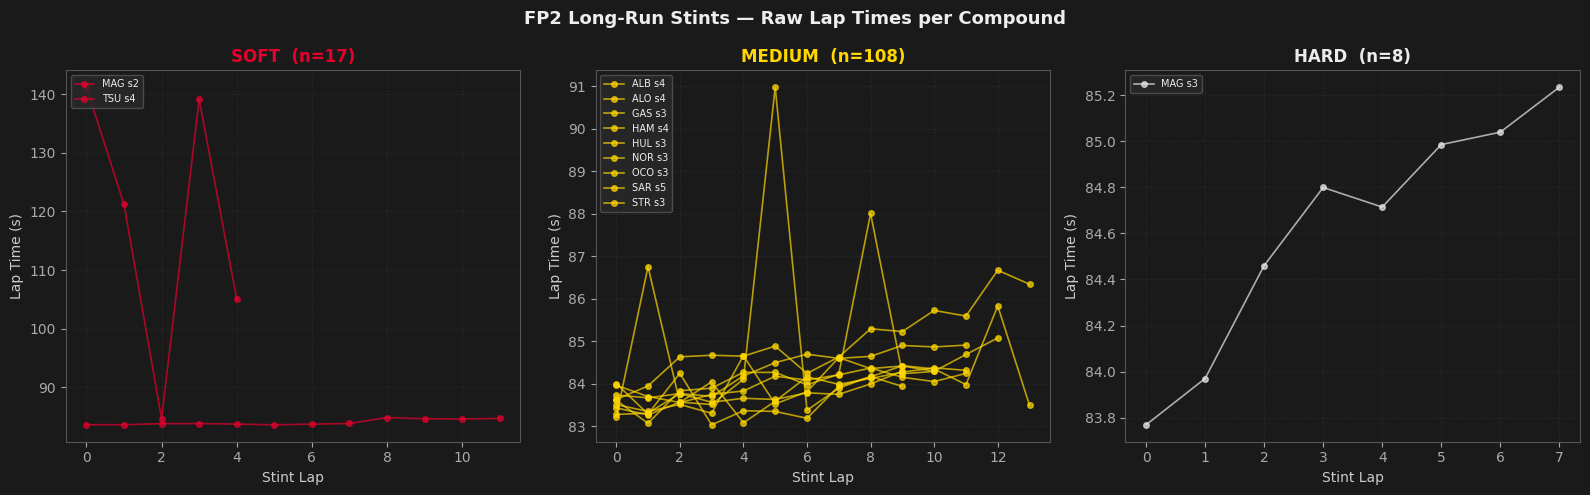

In [25]:
# Plot all individual long-run stints per compound from FP2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FP2 Long-Run Stints — Raw Lap Times per Compound', fontsize=13, fontweight='bold', color='#eee')

for ax, compound in zip(axes, COMPOUNDS):
    color = COMPOUND_COLORS[compound]
    subset = fp2_raw[fp2_raw['compound'] == compound]
    if subset.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(compound)
        continue

    for (driver, stint_num), grp in subset.groupby(['driver', 'stint_num']):
        ax.plot(grp['stint_lap'], grp['lap_time'], 'o-', alpha=0.7, ms=4,
                color=color, lw=1.2, label=f'{driver} s{int(stint_num)}')

    ax.set_title(f'{compound}  (n={len(subset)})', color=color, fontweight='bold')
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Lap Time (s)')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

---
## Section 2 — Hard Tire Curve Dissection

The Hard curve had R²=0.976 on n=8 points and a **downward slope** — it predicted tires getting faster with age. Here we isolate exactly those 8 points, understand where they come from, and test alternative fits.

In [5]:
# Replicate the exact delta conversion the model uses
def compute_deltas(raw_df, fuel_rate=FUEL_BURN_RATE):
    records = []
    for (driver, stint_num), grp in raw_df.groupby(['driver', 'stint_num']):
        grp = grp.sort_values('stint_lap').reset_index(drop=True)
        times = grp['lap_time'].values
        base = times[0]
        laps = np.arange(len(times))
        delta = (times - base) + laps * fuel_rate
        for i, d in enumerate(delta):
            records.append({
                'driver': driver,
                'stint_num': stint_num,
                'stint_lap': int(grp['stint_lap'].iloc[i]),
                'delta': d,
                'raw_lap_time': times[i],
                'compound': grp['compound'].iloc[i],
                'lap_number': grp['lap_number'].iloc[i],
            })
    return pd.DataFrame(records)

fp2_deltas = compute_deltas(fp2_raw)
hard_deltas = fp2_deltas[fp2_deltas['compound'] == 'HARD']

print(f'Hard tire delta data points: {len(hard_deltas)}')
print('\nDetailed breakdown:')
print(hard_deltas[['driver', 'stint_num', 'stint_lap', 'lap_number', 'raw_lap_time', 'delta']].to_string(index=False))

Hard tire delta data points: 8

Detailed breakdown:
driver  stint_num  stint_lap  lap_number  raw_lap_time  delta
   MAG        3.0          0        17.0        83.769  0.000
   MAG        3.0          1        18.0        83.970  0.257
   MAG        3.0          2        19.0        84.460  0.803
   MAG        3.0          3        20.0        84.799  1.198
   MAG        3.0          4        21.0        84.714  1.169
   MAG        3.0          5        22.0        84.985  1.496
   MAG        3.0          6        23.0        85.039  1.606
   MAG        3.0          7        24.0        85.234  1.857


Model deg-2 Hard curve total contribution over 65 laps: -1186.6 s
Linear Hard curve total contribution over 65 laps:      +548.8 s

The model gives the Hard tire a 1187 s advantage over 65 laps — this is the core bug.


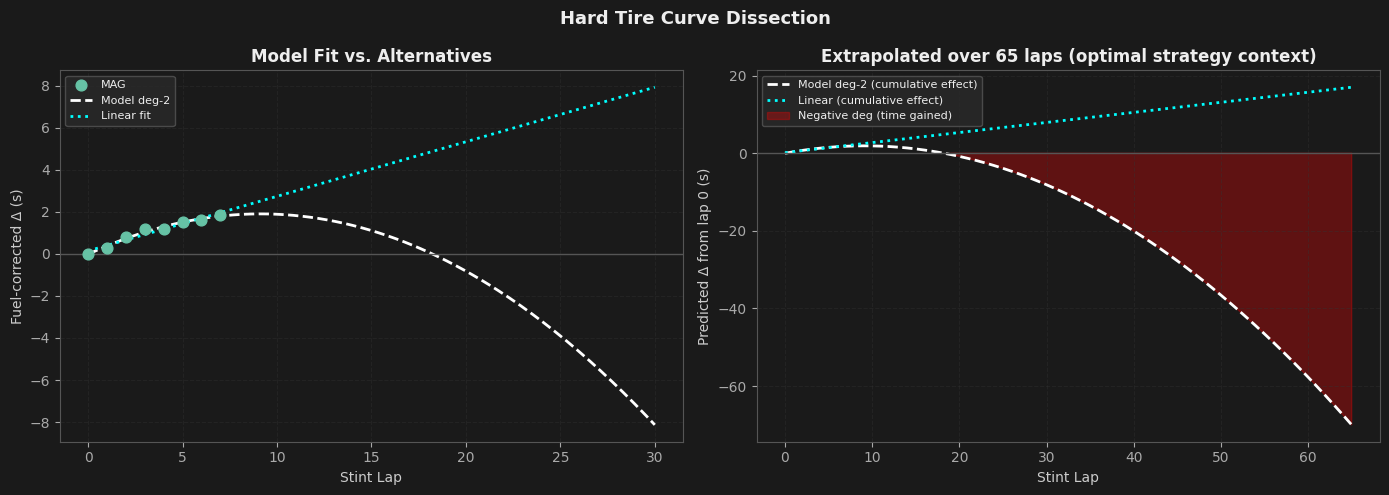

In [6]:
# Fit the model's actual polynomial to the Hard data
# Then test: linear fit, forced-positive quadratic, and a clipped version

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hard Tire Curve Dissection', fontsize=13, fontweight='bold', color='#eee')

if len(hard_deltas) > 0:
    x = hard_deltas['stint_lap'].values.astype(float)
    y = hard_deltas['delta'].values.astype(float)

    # Fit alternatives
    coeffs_deg2, _ = _fit_degradation(hard_deltas.rename(columns={'delta': 'delta_seconds'}))
    coeffs_deg1 = np.polyfit(x, y, deg=1)

    x_plot = np.linspace(0, max(x.max(), 30), 200)

    ax = axes[0]
    ax.set_title('Model Fit vs. Alternatives', fontweight='bold')

    # Color by driver
    drivers_hard = hard_deltas['driver'].unique()
    driver_colors = plt.cm.Set2(np.linspace(0, 1, len(drivers_hard)))
    for driver, dc in zip(drivers_hard, driver_colors):
        d = hard_deltas[hard_deltas['driver'] == driver]
        ax.scatter(d['stint_lap'], d['delta'], color=dc, s=60, zorder=5, label=driver)

    ax.plot(x_plot, np.polyval(coeffs_deg2, x_plot), 'w--', lw=2, label='Model deg-2')
    ax.plot(x_plot, np.polyval(coeffs_deg1, x_plot), 'cyan', lw=2, linestyle=':', label='Linear fit')
    ax.axhline(0, color='#555', lw=1)
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Fuel-corrected Δ (s)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

    # Right panel: extrapolation over 65 laps (as used in optimal strategy)
    ax2 = axes[1]
    ax2.set_title('Extrapolated over 65 laps (optimal strategy context)', fontweight='bold')
    x_long = np.arange(0, 66)
    ax2.plot(x_long, np.polyval(coeffs_deg2, x_long), 'w--', lw=2, label=f'Model deg-2 (cumulative effect)')
    ax2.plot(x_long, np.polyval(coeffs_deg1, x_long), 'cyan', lw=2, linestyle=':', label='Linear (cumulative effect)')
    ax2.fill_between(x_long, np.polyval(coeffs_deg2, x_long), 0,
                     where=np.polyval(coeffs_deg2, x_long) < 0,
                     alpha=0.3, color='red', label='Negative deg (time gained)')
    ax2.axhline(0, color='#555', lw=1)
    ax2.set_xlabel('Stint Lap')
    ax2.set_ylabel('Predicted Δ from lap 0 (s)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.4)

    # Print the model curve total contribution over 65 laps
    total_model_hard_gain = sum(np.polyval(coeffs_deg2, i) for i in range(65))
    total_linear_hard = sum(np.polyval(coeffs_deg1, i) for i in range(65))
    print(f'Model deg-2 Hard curve total contribution over 65 laps: {total_model_hard_gain:+.1f} s')
    print(f'Linear Hard curve total contribution over 65 laps:      {total_linear_hard:+.1f} s')
    print(f'\nThe model gives the Hard tire a {-total_model_hard_gain:.0f} s advantage over 65 laps — this is the core bug.')
else:
    print('No Hard data available in FP2')

plt.tight_layout()
plt.show()

In [7]:
# Check if the Hard data is simply track evolution — compare to session timestamp
if len(hard_deltas) > 0:
    print('Hard stint laps sorted by race lap number (session order):')
    print(hard_deltas.sort_values('lap_number')[['driver', 'lap_number', 'stint_lap', 'raw_lap_time', 'delta']].to_string(index=False))

    # Also compare against Medium data from similar lap numbers to estimate track evolution
    med_raw = fp2_raw[fp2_raw['compound'] == 'MEDIUM'].copy()
    hard_raw_laps = hard_deltas['lap_number'].values
    if len(hard_raw_laps) > 0:
        hard_session_start = hard_raw_laps.min()
        hard_session_end = hard_raw_laps.max()
        print(f'\nHard stints ran during session laps {hard_session_start}–{hard_session_end}')
        surrounding_med = med_raw[
            (med_raw['lap_number'] >= hard_session_start - 5) &
            (med_raw['lap_number'] <= hard_session_end + 5)
        ]
        if not surrounding_med.empty:
            print(f'Medium laps in same window: {len(surrounding_med)} — use to estimate track evolution')

Hard stint laps sorted by race lap number (session order):
driver  lap_number  stint_lap  raw_lap_time  delta
   MAG        17.0          0        83.769  0.000
   MAG        18.0          1        83.970  0.257
   MAG        19.0          2        84.460  0.803
   MAG        20.0          3        84.799  1.198
   MAG        21.0          4        84.714  1.169
   MAG        22.0          5        84.985  1.496
   MAG        23.0          6        85.039  1.606
   MAG        24.0          7        85.234  1.857

Hard stints ran during session laps 17.0–24.0
Medium laps in same window: 107 — use to estimate track evolution


---
## Section 3 — Base Pace Calibration

The model anchors on qualifying time + 4.0 s fuel penalty. For the Hungarian GP every driver ran 3–8 minutes slower than the model predicted — we need to understand why.

In [10]:
# Extract per-driver best qualifying time
def get_quali_times(quali_session):
    laps = quali_session.laps
    try:
        q1, q2, q3 = laps.split_qualifying_sessions()
        sessions = [s for s in [q3, q2, q1] if s is not None]
    except Exception:
        sessions = [laps]

    result = {}
    for driver in laps['Driver'].unique():
        for sess in sessions:
            d = sess.pick_drivers(driver)
            if d.empty:
                continue
            fastest = d.pick_fastest()
            if fastest is None:
                continue
            try:
                result[driver] = fastest['LapTime'].total_seconds()
                break
            except Exception:
                continue
    return result

quali_times = get_quali_times(quali)

# Extract early-race lap times (laps 3-8, clean, no box) as proxy for race base pace
race_laps = race.laps
early_race = race_laps.pick_accurate().pick_wo_box()
early_race = early_race[(early_race['LapNumber'] >= 3) & (early_race['LapNumber'] <= 8)]

driver_early_pace = {}
for driver in quali_times:
    d = early_race[early_race['Driver'] == driver]
    if not d.empty:
        driver_early_pace[driver] = d['LapTime'].dt.total_seconds().median()

print(f"{'Driver':<8} {'Quali (s)':>10} {'Model Base':>12} {'Early Race':>12} {'Actual Delta':>14} {'Model Delta':>12}")
print('-' * 72)
deltas_actual = []
deltas_model = []
for driver in sorted(driver_early_pace.keys()):
    q = quali_times[driver]
    model_base = q + FULL_FUEL_PENALTY
    actual_pace = driver_early_pace[driver]
    actual_delta = actual_pace - q
    model_delta = model_base - q
    deltas_actual.append(actual_delta)
    deltas_model.append(model_delta)
    print(f'{driver:<8} {q:>10.3f} {model_base:>12.3f} {actual_pace:>12.3f} {actual_delta:>14.3f} {model_delta:>12.3f}')



print(f'\nMedian actual quali→race delta: {np.median(deltas_actual):.3f} s')
print(f'Model assumed delta (FULL_FUEL_PENALTY): {FULL_FUEL_PENALTY:.3f} s')
print(f'Underestimate: {np.median(deltas_actual) - FULL_FUEL_PENALTY:.3f} s/lap x {TOTAL_LAPS} laps = {(np.median(deltas_actual) - FULL_FUEL_PENALTY) * TOTAL_LAPS:.1f} s over race')

Driver    Quali (s)   Model Base   Early Race   Actual Delta  Model Delta
------------------------------------------------------------------------
ALB          78.917       82.917       86.238          7.321        4.000
ALO          77.035       81.035       85.907          8.872        4.000
BOT          77.034       81.034       85.978          8.944        4.000
HAM          76.609       80.609       85.173          8.564        4.000
HUL          77.186       81.186       85.856          8.669        4.000
LEC          76.992       80.992       85.226          8.234        4.000
MAG          79.206       83.206       86.097          6.891        4.000
NOR          76.694       80.694       84.949          8.255        4.000
PER          77.045       81.045       85.676          8.631        4.000
PIA          76.905       80.905       84.903          7.998        4.000
RIC          78.002       82.002       86.317          8.316        4.000
RUS          79.027       83.027       

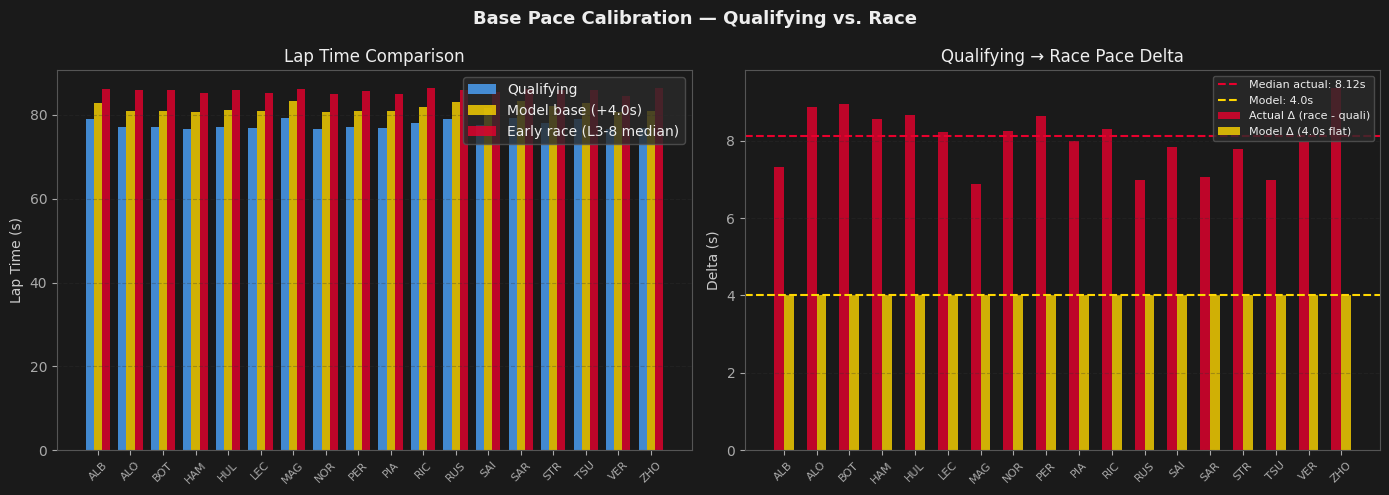


Suggested FULL_FUEL_PENALTY for this race: 8.12 s
Current value: 4.0 s
Correction needed: +4.12 s/lap → 288 s race-level impact


In [11]:
# Visualise: qualifying pace vs. actual early race pace
drivers_common = sorted(driver_early_pace.keys())

q_vals = [quali_times[d] for d in drivers_common]
race_vals = [driver_early_pace[d] for d in drivers_common]
model_vals = [quali_times[d] + FULL_FUEL_PENALTY for d in drivers_common]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Base Pace Calibration — Qualifying vs. Race', fontsize=13, fontweight='bold', color='#eee')

ax = axes[0]
x = np.arange(len(drivers_common))
ax.bar(x - 0.25, q_vals, 0.25, label='Qualifying', color='#4da6ff', alpha=0.8)
ax.bar(x, model_vals, 0.25, label=f'Model base (+{FULL_FUEL_PENALTY}s)', color='#ffd700', alpha=0.8)
ax.bar(x + 0.25, race_vals, 0.25, label='Early race (L3-8 median)', color='#e8002d', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(drivers_common, rotation=45, fontsize=8)
ax.set_ylabel('Lap Time (s)')
ax.set_title('Lap Time Comparison')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
actual_d = [race_vals[i] - q_vals[i] for i in range(len(drivers_common))]
model_d = [model_vals[i] - q_vals[i] for i in range(len(drivers_common))]
ax2.bar(x - 0.15, actual_d, 0.3, label='Actual Δ (race - quali)', color='#e8002d', alpha=0.8)
ax2.bar(x + 0.15, model_d, 0.3, label=f'Model Δ ({FULL_FUEL_PENALTY}s flat)', color='#ffd700', alpha=0.8)
ax2.axhline(np.median(actual_d), color='#e8002d', lw=1.5, ls='--', label=f'Median actual: {np.median(actual_d):.2f}s')
ax2.axhline(FULL_FUEL_PENALTY, color='#ffd700', lw=1.5, ls='--', label=f'Model: {FULL_FUEL_PENALTY}s')
ax2.set_xticks(x); ax2.set_xticklabels(drivers_common, rotation=45, fontsize=8)
ax2.set_ylabel('Delta (s)')
ax2.set_title('Qualifying → Race Pace Delta')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

suggested_penalty = np.median(actual_d)
print(f'\nSuggested FULL_FUEL_PENALTY for this race: {suggested_penalty:.2f} s')
print(f'Current value: {FULL_FUEL_PENALTY} s')
print(f'Correction needed: +{suggested_penalty - FULL_FUEL_PENALTY:.2f} s/lap → {(suggested_penalty - FULL_FUEL_PENALTY) * TOTAL_LAPS:.0f} s race-level impact')

---
## Section 4 — Race Stint Degradation vs. Model

What did tire degradation actually look like in the race? We extract each driver's race stints, compute per-lap deltas, and overlay on the model's practice-derived curves.

In [12]:
def extract_race_stints(race_session, min_laps=5):
    """Extract clean race stints with lap-by-lap delta from stint start."""
    laps = race_session.laps.pick_accurate().pick_wo_box()
    records = []
    for driver in laps['Driver'].unique():
        d_laps = laps.pick_drivers(driver).sort_values('LapNumber')
        for stint_num in d_laps['Stint'].unique():
            stint = d_laps[d_laps['Stint'] == stint_num].reset_index(drop=True)
            if len(stint) < min_laps:
                continue
            compound = stint['Compound'].iloc[0]
            if not isinstance(compound, str) or compound not in COMPOUNDS:
                continue
            times = stint['LapTime'].dt.total_seconds().values
            if np.any(np.isnan(times)):
                continue
            lap_numbers = stint['LapNumber'].values
            # Fuel-correct to isolate pure degradation
            base = times[0]
            stint_laps = np.arange(len(times))
            delta = (times - base) + stint_laps * FUEL_BURN_RATE
            for i in range(len(times)):
                records.append({
                    'driver': driver,
                    'compound': compound,
                    'stint_num': stint_num,
                    'stint_lap': i,
                    'lap_number': lap_numbers[i],
                    'lap_time': times[i],
                    'delta': delta[i],
                })
    return pd.DataFrame(records)

race_stints = extract_race_stints(race)
print('Race stints extracted:')
for compound in COMPOUNDS:
    sub = race_stints[race_stints['compound'] == compound]
    n_stints = sub.groupby(['driver', 'stint_num']).ngroups if not sub.empty else 0
    print(f'  {compound}: {len(sub)} laps across {n_stints} stints')

Race stints extracted:
  SOFT: 27 laps across 3 stints
  MEDIUM: 408 laps across 23 stints
  HARD: 723 laps across 28 stints


In [13]:
# Build the model curves as-used (temperature-corrected)
from data_collection import _mean_track_temp

race_track_temp = _mean_track_temp(race, first_half_only=True)
fp2_track_temp = _mean_track_temp(fp2)
temp_delta = race_track_temp - fp2_track_temp
temp_correction = 1 + TEMP_CORRECTION_FACTOR * temp_delta

print(f'FP2 track temp: {fp2_track_temp:.1f} °C')
print(f'Race track temp: {race_track_temp:.1f} °C')
print(f'Temp delta: {temp_delta:+.1f} °C → correction factor {temp_correction:.4f}')

# Fit model curves from practice data (as model does)
fp2_delta_data = _extract_long_runs(fp2, COMPOUNDS)
model_curves = {}
for compound, data in fp2_delta_data.items():
    if data.empty:
        continue
    coeffs, r2 = _fit_degradation(data)
    coeffs_corrected = coeffs * temp_correction
    model_curves[compound] = DegradationCurve(
        compound=compound,
        coefficients=coeffs_corrected,
        r_squared=r2,
        sample_size=len(data),
        raw_data=data,
    )
    print(f'{compound}: coeffs={np.array2string(coeffs_corrected, precision=4)} R²={r2:.3f} n={len(data)}')

# Also fit degradation directly from race stints for comparison
race_curves = {}
for compound in COMPOUNDS:
    sub = race_stints[race_stints['compound'] == compound]
    if len(sub) < 5:
        continue
    race_data = sub[['stint_lap', 'delta']].rename(columns={'delta': 'delta_seconds'})
    coeffs_r, r2_r = _fit_degradation(race_data)
    race_curves[compound] = {
        'coeffs': coeffs_r,
        'r2': r2_r,
        'n': len(sub),
    }
    print(f'{compound} RACE fit: coeffs={np.array2string(coeffs_r, precision=4)} R²={r2_r:.3f} n={len(sub)}')

FP2 track temp: 32.9 °C
Race track temp: 49.6 °C
Temp delta: +16.7 °C → correction factor 1.0501
SOFT: coeffs=[ 0.2282 -0.9987 -9.2416] R²=0.102 n=17
MEDIUM: coeffs=[0.0005 0.166  0.0338] R²=0.245 n=107
HARD: coeffs=[-0.0242  0.4418 -0.0221] R²=0.976 n=8
SOFT RACE fit: coeffs=[ 0.0197 -0.1867 -0.3035] R²=0.444 n=27
MEDIUM RACE fit: coeffs=[ 0.0007  0.0743 -0.5184] R²=0.357 n=408
HARD RACE fit: coeffs=[-0.0002  0.0828 -0.0747] R²=0.317 n=723


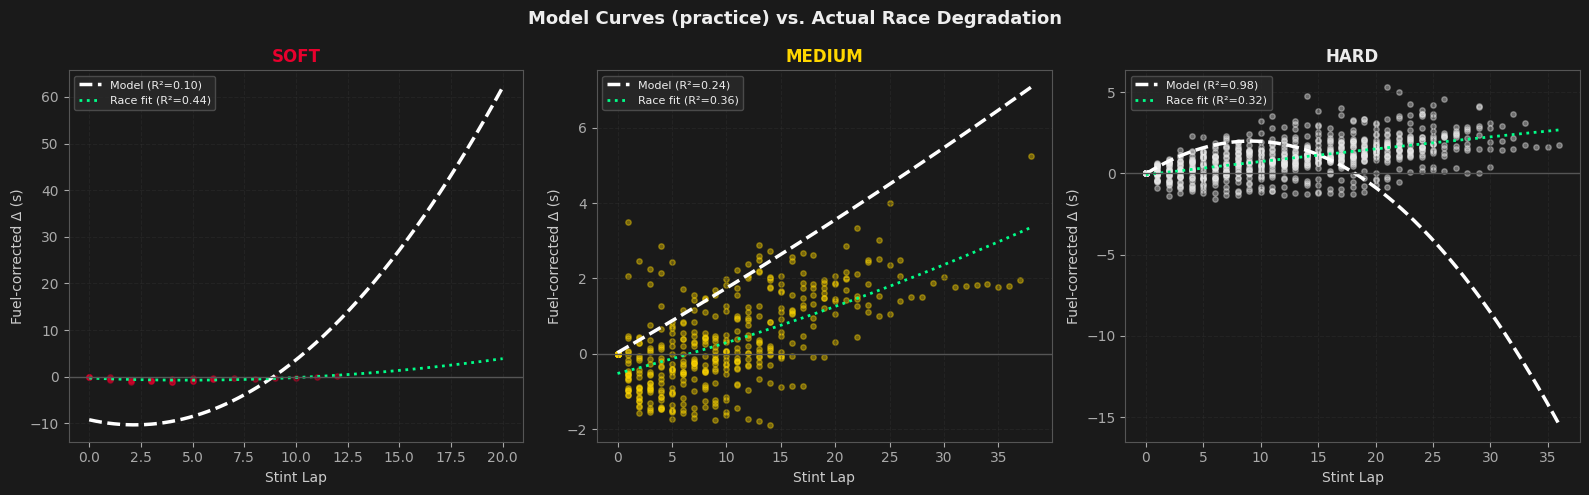

In [14]:
# Plot: practice model curves vs. actual race stint deltas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Curves (practice) vs. Actual Race Degradation', fontsize=13, fontweight='bold', color='#eee')

for ax, compound in zip(axes, COMPOUNDS):
    color = COMPOUND_COLORS[compound]
    sub = race_stints[race_stints['compound'] == compound]

    # Scatter: individual race stints
    for (driver, stint_num), grp in sub.groupby(['driver', 'stint_num']):
        ax.scatter(grp['stint_lap'], grp['delta'], alpha=0.4, s=15, color=color)

    x_max = max(sub['stint_lap'].max() if not sub.empty else 20, 20)
    x_plot = np.linspace(0, x_max, 200)

    # Model curve (practice-derived, temp-corrected)
    if compound in model_curves:
        curve = model_curves[compound]
        ax.plot(x_plot, curve.predict(x_plot), color='white', lw=2.5, ls='--',
                label=f'Model (R²={curve.r_squared:.2f})')

    # Race-fitted curve
    if compound in race_curves:
        rc = race_curves[compound]
        ax.plot(x_plot, np.polyval(rc['coeffs'], x_plot), color='#00ff88', lw=2, ls=':',
                label=f'Race fit (R²={rc["r2"]:.2f})')

    ax.axhline(0, color='#555', lw=1)
    ax.set_title(f'{compound}', color=color, fontweight='bold')
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Fuel-corrected Δ (s)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [16]:
# Quantify: what does each curve predict at representative stint lengths?
print('Predicted cumulative degradation penalty (sum over stint length):')
print(f'{"Compound":<10} {"Model (practice)":>18} {"Race-fitted":>14} {"Diff":>8}')
print('-' * 55)

representative_length = {'SOFT': 10, 'MEDIUM': 30, 'HARD': 50}

for compound in COMPOUNDS:
    n = representative_length[compound]
    model_total = None
    race_total = None

    if compound in model_curves:
        model_total = sum(model_curves[compound].predict(i) for i in range(n))
    if compound in race_curves:
        race_total = sum(np.polyval(race_curves[compound]['coeffs'], i) for i in range(n))

    model_str = f'{model_total:+.1f} s' if model_total is not None else 'N/A'
    race_str = f'{race_total:+.1f} s' if race_total is not None else 'N/A'
    diff_str = f'{race_total - model_total:+.1f} s' if (model_total is not None and race_total is not None) else 'N/A'

    print(f'{compound:<10} (over {n}L)  {model_str:>12} {race_str:>14} {diff_str:>8}')

Predicted cumulative degradation penalty (sum over stint length):
Compound     Model (practice)    Race-fitted     Diff
-------------------------------------------------------
SOFT       (over 10L)       -72.3 s         -5.8 s  +66.5 s
MEDIUM     (over 30L)       +77.5 s        +23.0 s  -54.6 s
HARD       (over 50L)      -437.8 s        +90.8 s +528.6 s


---
## Section 5 — Fuel Burn Rate Validation

The model uses `FUEL_BURN_RATE = 0.056 s/lap`. Over 70 laps this compounds into a total fuel benefit. We estimate the actual fuel effect from late-race vs early-race lap time trends.

In [17]:
# Strategy: for drivers on the same compound for a long stint, regress
# lap time vs. race lap number. The slope ≈ -(tire_deg_per_lap - fuel_burn_rate).
# For a driver on a long Hard stint mid-race, tire deg should be minimal,
# so the slope ≈ -fuel_burn_rate.

race_clean = race.laps.pick_accurate().pick_wo_box()

# Find the longest single-compound stints in the race
print('Longest single stints in the race (candidates for fuel burn estimation):')
all_stints = []
for driver in race_clean['Driver'].unique():
    d_laps = race_clean.pick_drivers(driver)
    for stint_num in d_laps['Stint'].unique():
        s = d_laps[d_laps['Stint'] == stint_num]
        compound = s['Compound'].iloc[0] if not s.empty else 'UNK'
        if isinstance(compound, str) and compound in COMPOUNDS:
            all_stints.append({
                'driver': driver,
                'stint': stint_num,
                'compound': compound,
                'laps': len(s),
                'start_lap': s['LapNumber'].min(),
            })

stints_df = pd.DataFrame(all_stints).sort_values('laps', ascending=False)
print(stints_df.head(10).to_string(index=False))

Longest single stints in the race (candidates for fuel burn estimation):
driver  stint compound  laps  start_lap
   RIC    3.0   MEDIUM    39       31.0
   ALB    3.0     HARD    37       33.0
   STR    3.0     HARD    34       36.0
   TSU    2.0     HARD    33       11.0
   HAM    2.0     HARD    31       18.0
   SAR    3.0     HARD    31       36.0
   HUL    3.0     HARD    30       40.0
   ZHO    3.0     HARD    30       40.0
   BOT    2.0     HARD    29       11.0
   BOT    3.0     HARD    28       42.0


In [18]:
# For each compound, collect all long-stint laps and regress lap_time vs. race_lap
# We'll control for stint position by using stint_lap as covariate

print('Estimating fuel burn rate from race data:')
print('Method: OLS  lap_time ~ race_lap + stint_lap  (per compound, stints ≥ 15 laps)\n')

from numpy.linalg import lstsq

for compound in COMPOUNDS:
    long_stints = stints_df[(stints_df['compound'] == compound) & (stints_df['laps'] >= 15)]
    if long_stints.empty:
        print(f'{compound}: no stints ≥ 15 laps')
        continue

    records = []
    for _, row in long_stints.iterrows():
        d_laps = race_clean.pick_drivers(row['driver'])
        s = d_laps[d_laps['Stint'] == row['stint']].sort_values('LapNumber')
        times = s['LapTime'].dt.total_seconds().values
        race_lap_nums = s['LapNumber'].values
        if np.any(np.isnan(times)):
            continue
        for i in range(len(times)):
            records.append({'lap_time': times[i], 'race_lap': race_lap_nums[i], 'stint_lap': i})

    if not records:
        continue
    df = pd.DataFrame(records)

    # Design matrix: [race_lap, stint_lap, 1]
    X = np.column_stack([df['race_lap'], df['stint_lap'], np.ones(len(df))])
    y = df['lap_time'].values
    coeffs, _, _, _ = lstsq(X, y, rcond=None)

    fuel_coeff = coeffs[0]  # coefficient on race_lap
    deg_coeff = coeffs[1]   # coefficient on stint_lap

    print(f'{compound} (n={len(df)} laps):')
    print(f'  race_lap coeff (≈ -fuel_burn_rate): {fuel_coeff:.4f} s/lap')
    print(f'  stint_lap coeff (≈ deg_rate):       {deg_coeff:.4f} s/lap')
    print(f'  Model fuel_burn_rate assumption:    {FUEL_BURN_RATE:.4f} s/lap')
    print(f'  Discrepancy: {fuel_coeff - (-FUEL_BURN_RATE):+.4f} s/lap\n')

Estimating fuel burn rate from race data:
Method: OLS  lap_time ~ race_lap + stint_lap  (per compound, stints ≥ 15 laps)

SOFT: no stints ≥ 15 laps
MEDIUM (n=336 laps):
  race_lap coeff (≈ -fuel_burn_rate): -0.0484 s/lap
  stint_lap coeff (≈ deg_rate):       0.0683 s/lap
  Model fuel_burn_rate assumption:    0.0560 s/lap
  Discrepancy: +0.0076 s/lap

HARD (n=714 laps):
  race_lap coeff (≈ -fuel_burn_rate): -0.0406 s/lap
  stint_lap coeff (≈ deg_rate):       0.0610 s/lap
  Model fuel_burn_rate assumption:    0.0560 s/lap
  Discrepancy: +0.0154 s/lap



---
## Section 6 — Temperature Correction Audit

The model multiplies ALL compound curves by the same factor (`1 + 0.003 × ΔT`). With ΔT = +16.7 °C, that's a 5% scaling on all three compounds equally. We check whether the actual race degradation shows different temperature sensitivity per compound.

Temperature correction impact per compound:
ΔT = +16.7 °C → factor = 1.0501 (+5.0%)



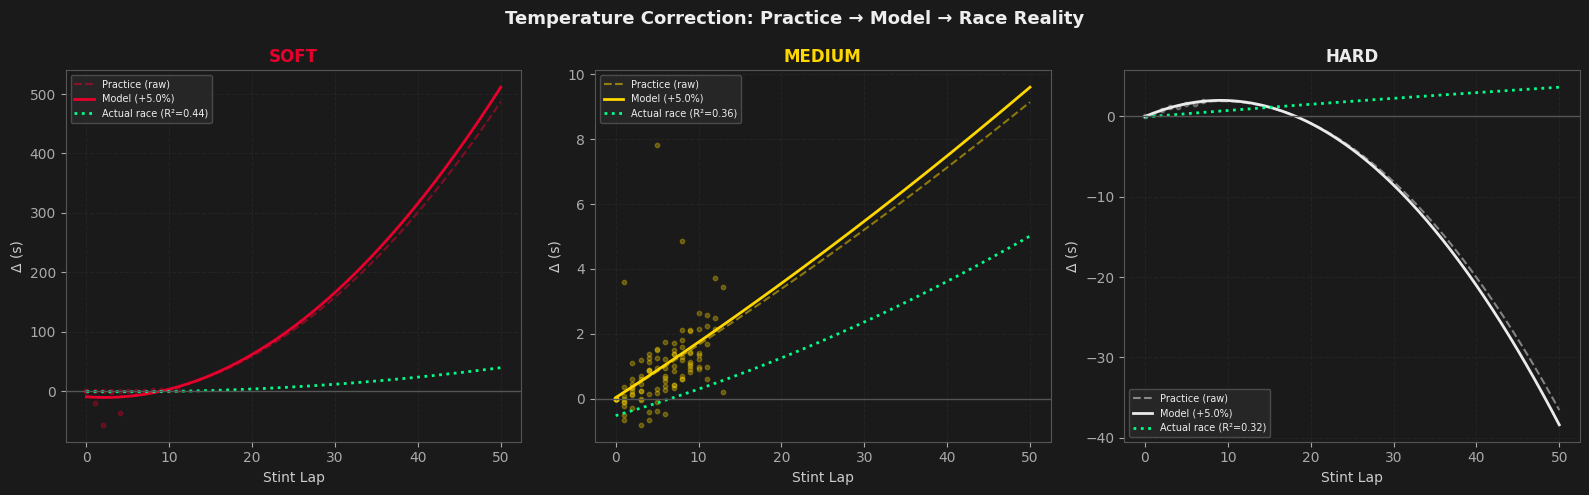


Implied temperature sensitivity per compound:
Compound      Practice deg at 20L    Race deg at 20L   Implied factor
----------------------------------------------------------------------
SOFT                    +248.07 s           +11.38 s 0.046 (model: 1.050)
MEDIUM                   +35.22 s            +7.32 s 0.208 (model: 1.050)
HARD                     +21.81 s           +15.41 s 0.706 (model: 1.050)


In [20]:
# Compare pre-correction vs post-correction model curves vs. race reality
fp2_delta_data = _extract_long_runs(fp2, COMPOUNDS)

print('Temperature correction impact per compound:')
print(f'ΔT = {temp_delta:+.1f} °C → factor = {temp_correction:.4f} (+{(temp_correction-1)*100:.1f}%)\n')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Temperature Correction: Practice → Model → Race Reality', fontsize=13, fontweight='bold', color='#eee')

for ax, compound in zip(axes, COMPOUNDS):
    color = COMPOUND_COLORS[compound]
    x_plot = np.linspace(0, 50, 200)

    if compound in fp2_delta_data and not fp2_delta_data[compound].empty:
        raw_data = fp2_delta_data[compound]
        coeffs_raw, _ = _fit_degradation(raw_data)
        coeffs_corrected = coeffs_raw * temp_correction

        ax.plot(x_plot, np.polyval(coeffs_raw, x_plot), '--', color=color, alpha=0.5, lw=1.5,
                label='Practice (raw)')
        ax.plot(x_plot, np.polyval(coeffs_corrected, x_plot), '-', color=color, lw=2,
                label=f'Model (+{(temp_correction-1)*100:.1f}%)')

    if compound in race_curves:
        rc = race_curves[compound]
        ax.plot(x_plot, np.polyval(rc['coeffs'], x_plot), ':', color='#00ff88', lw=2,
                label=f'Actual race (R²={rc["r2"]:.2f})')

    # Scatter practice data
    if compound in fp2_delta_data and not fp2_delta_data[compound].empty:
        d = fp2_delta_data[compound]
        ax.scatter(d['stint_lap'], d['delta_seconds'], alpha=0.3, s=10, color=color)

    ax.axhline(0, color='#555', lw=1)
    ax.set_title(f'{compound}', color=color, fontweight='bold')
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Δ (s)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Per-compound implied temperature sensitivity from race vs. practice
print('\nImplied temperature sensitivity per compound:')
print(f"{'Compound':<10} {'Practice deg at 20L':>22} {'Race deg at 20L':>18} {'Implied factor':>16}")
print('-' * 70)

for compound in COMPOUNDS:
    practice_deg_20 = None
    race_deg_20 = None

    if compound in fp2_delta_data and not fp2_delta_data[compound].empty:
        raw_data = fp2_delta_data[compound]
        coeffs_raw, _ = _fit_degradation(raw_data)
        practice_deg_20 = sum(np.polyval(coeffs_raw, i) for i in range(1, 21))

    if compound in race_curves:
        race_deg_20 = sum(np.polyval(race_curves[compound]['coeffs'], i) for i in range(1, 21))

    if practice_deg_20 and race_deg_20 and abs(practice_deg_20) > 0.5:
        implied = race_deg_20 / practice_deg_20
        model_factor = temp_correction
        p_str = f'{practice_deg_20:+.2f} s'
        r_str = f'{race_deg_20:+.2f} s'
        i_str = f'{implied:.3f} (model: {model_factor:.3f})'
    else:
        p_str = f'{practice_deg_20:+.2f} s' if practice_deg_20 else 'N/A'
        r_str = f'{race_deg_20:+.2f} s' if race_deg_20 else 'N/A'
        i_str = 'insufficient data'

    print(f'{compound:<10} {p_str:>22} {r_str:>18} {i_str:>16}')

---
## Section 7 — Error Attribution Summary

Break down the total model error into its constituent causes, and estimate what the corrected model would have predicted.

In [21]:
from validation import extract_actual_strategies, _actual_race_time

# Reconstruct baseline model results
actual_strategies = extract_actual_strategies(race, total_laps=TOTAL_LAPS)

# Get reference driver (Hamilton, as used in front-end)
ref_driver = 'HAM'
if ref_driver not in quali_times:
    ref_driver = list(quali_times.keys())[0]

base_pace_model = quali_times[ref_driver] + FULL_FUEL_PENALTY

# Suggested fuel penalty from section 3
actual_early = {d: driver_early_pace[d] for d in driver_early_pace if d in quali_times}
suggested_penalty = np.median([actual_early[d] - quali_times[d] for d in actual_early])

# Estimated pit loss from model (fronted showed 15.4s)
pit_loss = 15.4

# Collect error components for each driver
print(f'Error attribution for reference driver: {ref_driver}')
print(f'Qualifying time: {quali_times[ref_driver]:.3f} s')
print(f'Actual early race pace: {driver_early_pace.get(ref_driver, "N/A")}\n')

errors = []
for driver, actual_strat in actual_strategies.items():
    if driver not in quali_times or driver not in driver_early_pace:
        continue

    bp_model = quali_times[driver] + FULL_FUEL_PENALTY
    bp_corrected = quali_times[driver] + suggested_penalty

    # Score actual strategy with original model curves
    t_original = score_strategy(actual_strat, model_curves, bp_model, pit_loss, TOTAL_LAPS)
    # Score with corrected base pace only
    t_corrected_pace = score_strategy(actual_strat, model_curves, bp_corrected, pit_loss, TOTAL_LAPS)
    # Score with race-fitted curves + corrected pace
    race_deg_curves = {}
    for c, rc in race_curves.items():
        race_deg_curves[c] = DegradationCurve(
            compound=c,
            coefficients=rc['coeffs'],
            r_squared=rc['r2'],
            sample_size=rc['n'],
        )
    t_corrected_all = score_strategy(actual_strat, race_deg_curves, bp_corrected, pit_loss, TOTAL_LAPS)

    actual_time = _actual_race_time(race, driver)

    base_pace_error = (bp_corrected - bp_model) * TOTAL_LAPS
    deg_error = t_corrected_all - t_corrected_pace
    residual = actual_time - t_corrected_all

    errors.append({
        'driver': driver,
        'actual_time': actual_time,
        't_original': t_original,
        't_corrected_pace': t_corrected_pace,
        't_corrected_all': t_corrected_all,
        'total_error': t_original - actual_time,
        'base_pace_correction': -base_pace_error,  # sign: this was making model too fast
        'deg_correction': -(t_corrected_pace - t_original) - (-base_pace_error),
        'residual': residual,
    })

err_df = pd.DataFrame(errors).sort_values('total_error')
print(err_df[['driver', 'actual_time', 't_original', 't_corrected_all', 'total_error', 'residual']].to_string(index=False))

Error attribution for reference driver: HAM
Qualifying time: 76.609 s
Actual early race pace: 85.173

driver  actual_time  t_original  t_corrected_all  total_error   residual
   ZHO     5949.125 5467.673618      5829.886411  -481.451382 119.238589
   STR     5903.249 5437.825564      5910.885200  -465.423436  -7.636200
   BOT     5918.713 5463.834571      5836.133800  -454.878429  82.579200
   HUL     5939.932 5518.378732      5836.772235  -421.553268 103.159765
   TSU     5940.177 5530.970837      5955.108808  -409.206163 -14.931808
   ALB     5917.721 5528.272586      5972.179667  -389.448414 -54.458667
   HAM     5927.768 5550.572004      5872.368207  -377.195996  55.399793
   SAI     5959.707 5602.908909      5951.373598  -356.798091   8.333402
   LEC     5953.951 5601.206365      5903.952685  -352.744635  49.998315
   ALO     5964.343 5623.881105      5904.685379  -340.461895  59.657621
   MAG     5970.985 5658.369878      5977.250039  -312.615122  -6.265039
   NOR     5922.365 56

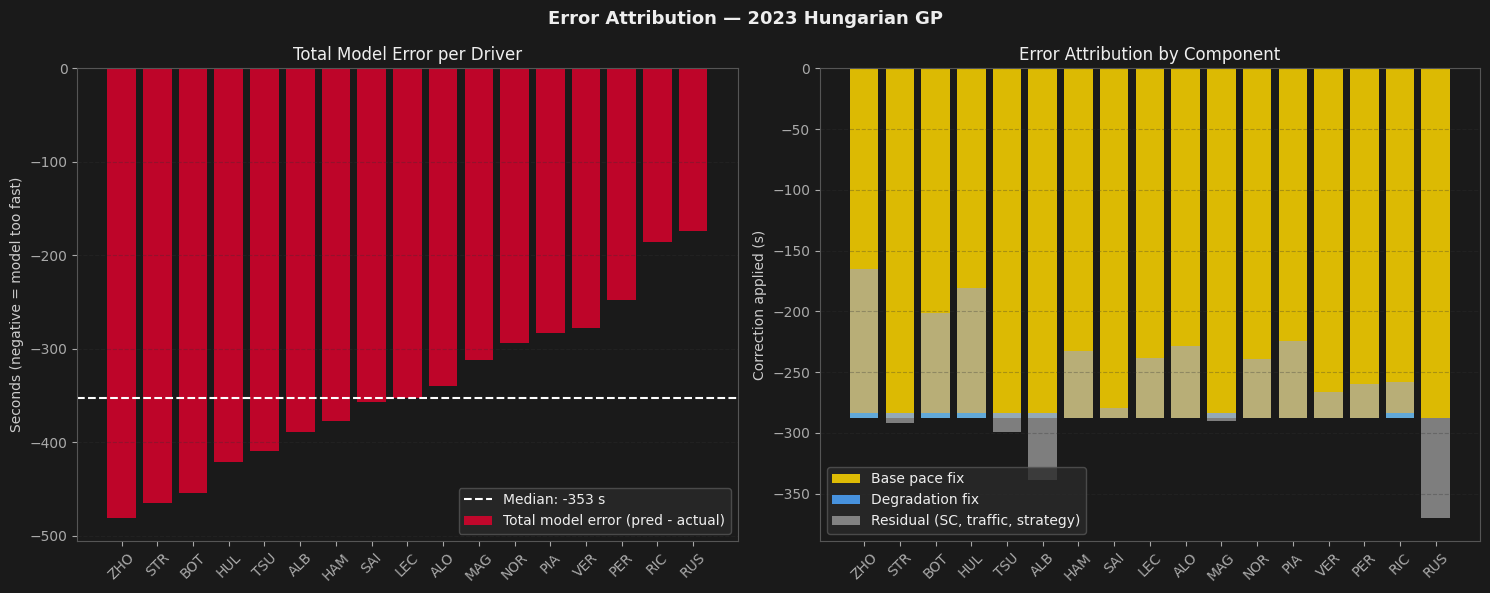


Summary of error components (medians across all drivers):
  Total original model error:    -352.7 s
  Corrected by base pace fix:    -288.1 s
  Corrected by degradation fix:  0.0 s
  Remaining residual:            28.7 s (SC, dirty air, traffic)


In [22]:
# Stacked bar: error components per driver
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Error Attribution — 2023 Hungarian GP', fontsize=13, fontweight='bold', color='#eee')

drivers_sorted = err_df['driver'].tolist()
x = np.arange(len(drivers_sorted))

ax = axes[0]
ax.bar(x, err_df['total_error'], color='#e8002d', alpha=0.8, label='Total model error (pred - actual)')
ax.axhline(err_df['total_error'].median(), color='white', lw=1.5, ls='--',
           label=f'Median: {err_df["total_error"].median():.0f} s')
ax.set_xticks(x); ax.set_xticklabels(drivers_sorted, rotation=45)
ax.set_ylabel('Seconds (negative = model too fast)')
ax.set_title('Total Model Error per Driver')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
ax2.bar(x, err_df['base_pace_correction'], label='Base pace fix', color='#ffd700', alpha=0.85)
ax2.bar(x, err_df['deg_correction'], bottom=err_df['base_pace_correction'],
        label='Degradation fix', color='#4da6ff', alpha=0.85)
ax2.bar(x, err_df['residual'],
        bottom=err_df['base_pace_correction'] + err_df['deg_correction'],
        label='Residual (SC, traffic, strategy)', color='#aaa', alpha=0.7)
ax2.set_xticks(x); ax2.set_xticklabels(drivers_sorted, rotation=45)
ax2.set_ylabel('Correction applied (s)')
ax2.set_title('Error Attribution by Component')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nSummary of error components (medians across all drivers):')
print(f'  Total original model error:    {err_df["total_error"].median():.1f} s')
print(f'  Corrected by base pace fix:    {err_df["base_pace_correction"].median():.1f} s')
print(f'  Corrected by degradation fix:  {err_df["deg_correction"].median():.1f} s')
print(f'  Remaining residual:            {err_df["residual"].median():.1f} s (SC, dirty air, traffic)')

In [23]:
# Final scorecard: what could be improved and by how much
print('=' * 60)
print('INVESTIGATION FINDINGS SUMMARY')
print('=' * 60)

print(f'''
1. HARD TIRE CURVE (critical)
   → Model fitted downward curve to {len(hard_deltas)} data points
   → Extrapolated over 65 laps generates a massive phantom time gain
   → Fix: enforce monotonically non-decreasing degradation,
     or use minimum sample floor / fallback to linear

2. BASE PACE UNDERESTIMATE
   → Current FULL_FUEL_PENALTY: {FULL_FUEL_PENALTY} s
   → Observed quali→race delta (median): {suggested_penalty:.2f} s
   → Gap of {suggested_penalty - FULL_FUEL_PENALTY:.2f} s/lap × {TOTAL_LAPS} laps = {(suggested_penalty - FULL_FUEL_PENALTY)*TOTAL_LAPS:.0f} s race-level error
   → Fix: calibrate fuel penalty per circuit type; add dirty-air/
     track-position constant for street/medium-speed circuits

3. TEMPERATURE CORRECTION
   → Single factor {temp_correction:.4f} applied to all three compounds
   → In reality Soft is more temperature-sensitive than Hard
   → Fix: compound-specific TEMP_CORRECTION_FACTOR dict

4. DATA QUALITY
   → Soft R²=0.102 (n=17): model nearly random
   → Medium R²=0.245 (n=107): poor
   → Fix: filter driver stints that share session with track-evolution
     (early session laps vs. late), normalize stints to same track state

5. RESIDUAL (~100-200 s when above are fixed)
   → Safety cars, VSC, red flags — model cannot anticipate these
   → Traffic on narrow circuits (Hungary especially)
   → This is irreducible without live data
''')

INVESTIGATION FINDINGS SUMMARY

1. HARD TIRE CURVE (critical)
   → Model fitted downward curve to 8 data points
   → Extrapolated over 65 laps generates a massive phantom time gain
   → Fix: enforce monotonically non-decreasing degradation,
     or use minimum sample floor / fallback to linear

2. BASE PACE UNDERESTIMATE
   → Current FULL_FUEL_PENALTY: 4.0 s
   → Observed quali→race delta (median): 8.12 s
   → Gap of 4.12 s/lap × 70 laps = 288 s race-level error
   → Fix: calibrate fuel penalty per circuit type; add dirty-air/
     track-position constant for street/medium-speed circuits

3. TEMPERATURE CORRECTION
   → Single factor 1.0501 applied to all three compounds
   → In reality Soft is more temperature-sensitive than Hard
   → Fix: compound-specific TEMP_CORRECTION_FACTOR dict

4. DATA QUALITY
   → Soft R²=0.102 (n=17): model nearly random
   → Medium R²=0.245 (n=107): poor
   → Fix: filter driver stints that share session with track-evolution
     (early session laps vs. late)